In [3]:
import pandas as pan
import matplotlib.pyplot as plt
import numpy as np

f0  = pan.read_csv("../data/experimental2/filtered/f0.csv")
f1  = pan.read_csv("../data/experimental2/filtered/f1.csv")
m0  = pan.read_csv("../data/experimental2/filtered/m0.csv")
m1  = pan.read_csv("../data/experimental2/filtered/m1.csv")

In [4]:
m0

,n,action_name,motivation,optional
0,1,weekly,-2,2 à 4 fois par mois
1,1,monthly,2,2 à 4 fois par mois
2,1,as_usual,2,2 à 4 fois par mois
3,2,weekly,-3,2 à 4 fois par mois
4,2,monthly,3,2 à 4 fois par mois
...,...,...,...,...
238,126,monthly,-1,1 fois par mois ou moins
239,126,as_usual,2,1 fois par mois ou moins
240,128,weekly,-2,1 fois par mois ou moins
241,128,monthly,2,1 fois par mois ou moins


In [5]:
m1

,n,action_name,motivation
0,1,weekly,2
1,1,monthly,2
2,1,notatall,-1
3,2,weekly,1
4,2,monthly,2
...,...,...,...
217,126,monthly,-2
218,126,notatall,-1
219,128,weekly,2
220,128,monthly,2


In [6]:
feedback_map = {"Oui":1, "Oui, mais pas sûr":0.5,"Non":0}
def compute_meanfeedback(df):
    feedbacks_per_motivation = {-3:[],-2:[],-1:[],0:[],1:[],2:[],3:[]}

    def update_feedbacks(row):
        if row["nfeedback"] != 0.8:
            feedbacks_per_motivation[row["motivation"]].append(row["nfeedback"])

    df["nfeedback"] = df["feedback"].map(feedback_map)
    df.apply(update_feedbacks,axis=1)

    feedbacks_per_motivation
    denulify = lambda  x: x+1*(x==0)
    meanfeedback_per_motivation = {k:sum(v)/(denulify(len(v))) for (k,v) in feedbacks_per_motivation.items()}
    feedbackerr_per_motvation = {k:np.std(v)/(np.sqrt(len(v)))for (k,v) in feedbacks_per_motivation.items()}
    x,y = [],[]
    for (k,v) in feedbacks_per_motivation.items():
        for j in v:
            x.append(k)
            y.append(j)
    model = np.polyfit(x,y,deg = 3)
    return meanfeedback_per_motivation,feedbackerr_per_motvation,model

def compute_meanfeedback_per_action(df):
    feedbacks_per_motivation_per_action = {"weekly":{-3:[],-2:[],-1:[],0:[],1:[],2:[],3:[]},"monthly":{-3:[],-2:[],-1:[],0:[],1:[],2:[],3:[]},"as_usual":{-3:[],-2:[],-1:[],0:[],1:[],2:[],3:[]}}

    def update_feedbacks(row):
        if row["nfeedback"] != 0.8:
            feedbacks_per_motivation_per_action[row["action_name"]][row["motivation"]].append(row["nfeedback"])
    
    

    df["nfeedback"] = df["feedback"].map(feedback_map)
    df.apply(update_feedbacks,axis=1)
    res = {}
    for ac in ["weekly","monthly","as_usual"]:
        feedbacks_per_motivation = feedbacks_per_motivation_per_action[ac]
        denulify = lambda  x: x+1*(x==0)
        meanfeedback_per_motivation = {k:sum(v)/(denulify(len(v))) for (k,v) in feedbacks_per_motivation.items()}
        feedbackerr_per_motvation = {k:np.std(v)/(np.sqrt(len(v)))for (k,v) in feedbacks_per_motivation.items()}
        x,y = [],[]
        for (k,v) in feedbacks_per_motivation.items():
            for j in v:
                x.append(k)
                y.append(j)
        model = np.polyfit(x,y,deg = 3)
        res[ac] = meanfeedback_per_motivation,feedbackerr_per_motvation,model
    return res

def plotting(meandic,errdic,model):
    meandic_items = meandic.items()
    x = [d[0]for d in meandic_items]
    y = [d[1]for d in meandic_items]
    err = [d[1] for d in errdic.items()]
    plt.errorbar(x,y,yerr=err,label="réalisation moyenne (avec sem)")
    x = np.linspace(-3,3,50)
    y = [np.polyval(model, i) for i in x]
    plt.plot(x,y,label = "modèle cubique")

/home/nov/.local/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/nov/.local/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/nov/.local/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


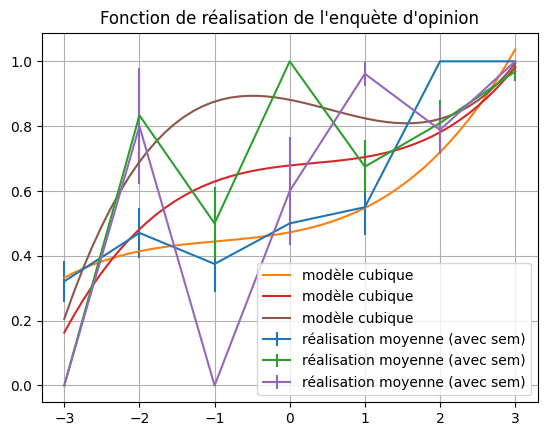

In [7]:
r0 = compute_meanfeedback_per_action(f0)
#mf1,ef1,model1 = compute_meanfeedback(f1)
for ac in ["weekly","monthly","as_usual"]:
    meandic,errdic,model = r0[ac]
    plotting(meandic,errdic,model)
#plotting(mf0,ef0,model0)
#plotting(mf1,ef1,model1)
plt.title("Fonction de réalisation de l'enquète d'opinion")
plt.legend()
plt.grid(visible=True)

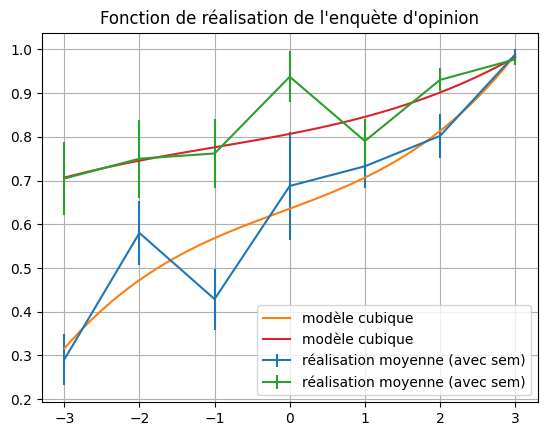

In [8]:
meandic,errdic,model  = compute_meanfeedback(f0)

plotting(meandic,errdic,model)
meandic,errdic,model  = compute_meanfeedback(f1)

plotting(meandic,errdic,model)
plt.title("Fonction de réalisation de l'enquète d'opinion")
plt.legend()
plt.grid(visible=True)

In [23]:
def compute_motiv_distrib(df,action_names):
    motiv_distrib = {ac:{-3:0,-2:0,-1:0,0:0,1:0,2:0,3:0}for ac in action_names}
    def update_distrib(row):
        motiv_distrib[row["action_name"]][row["motivation"]]+=1

    df.apply(update_distrib,axis=1) 
    coords = {ac:[[],[]] for ac in action_names}
    for ac in action_names:
        for (k,v) in motiv_distrib[ac].items():
            coords[ac][0].append(k)
            coords[ac][1].append(v)
    return coords,motiv_distrib

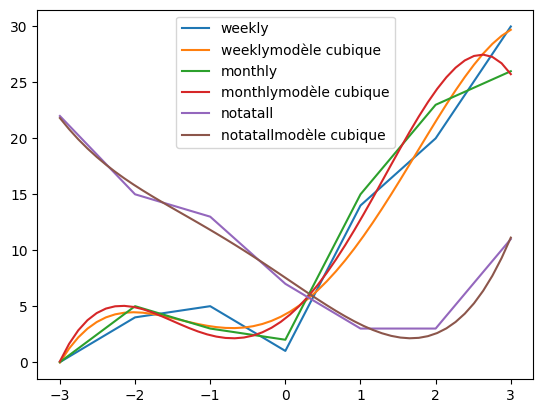

In [27]:
# actions0 = ["weekly","monthly","as_usual"]
# coords,motiv_distrib = compute_motiv_distrib(m0,actions0)
actions1 = ["weekly","monthly","notatall"]
coords,motiv_distrib = compute_motiv_distrib(m1,actions1)
for ac in actions1:
    x,y = coords[ac]
    plt.plot(x,y,label = ac)
    model = np.polyfit(x,y,deg = 4)
    x = np.linspace(-3,3,50)
    y = [np.polyval(model, i) for i in x]
    plt.plot(x,y,label = ac + "modèle cubique")
plt.legend()

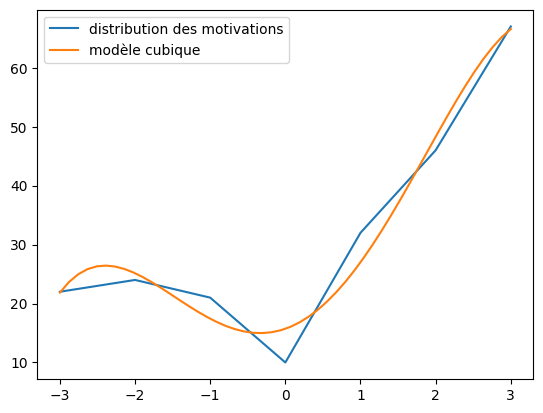

In [28]:
x,y = [],[]
combined_coords = {-3:0,-2:0,-1:0,0:0,1:0,2:0,3:0}
for ac in actions1:
    for (k,v) in motiv_distrib[ac].items():
        combined_coords[k]+=v

for (k,v) in combined_coords.items():
    x.append(k)
    y.append(v) 

plt.plot(x,y,label = "distribution des motivations")
model = np.polyfit(x,y,deg = 4)
x = np.linspace(-3,3,50)
y = [np.polyval(model, i) for i in x]
plt.plot(x,y,label = "modèle cubique")
plt.legend()